<a href="https://colab.research.google.com/github/bahaamhawad/bahaaawad_INFO4670_Spring2026/blob/main/Copy_of_HandsOn_Lecture6_AssociationRuleMining_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Task — Association Rule Mining (Lecture 6)

**Course:** INFO 4670  
**Focus:** Support, Confidence, Apriori, FP-Growth  

Run cells top-to-bottom. Fill short answers where prompted.


Setup → Toy Data Preprocessing → Apriori → Association Rule Generation → FP-Growth → Real Data Preprocessing → Real Data Rule Generation → Visualization (Optional).

## 0) Setup
If a package is missing locally, uncomment the `%pip install` lines and run once.

In [ ]:
import os
os.listdir()

['.config', 'bread_basket-2.csv', 'sample_data']

In [ ]:
%pip install pandas mlxtend matplotlib networkx

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules


## 1) Load a Small Transaction Dataset (Toy)
We start with a tiny dataset to make outputs easy to read.

In [ ]:
# Toy dataset with 5 transactions
transactions = [
    ["Milk", "Bread", "Butter"],
    ["Milk", "Bread"],
    ["Bread", "Butter"],
    ["Milk", "Bread", "Eggs"],
    ["Milk", "Eggs"]
]

pd.DataFrame({"TID": [f"T{i+1}" for i in range(len(transactions))],
              "Items": [", ".join(t) for t in transactions]})


,TID,Items
0,T1,"Milk, Bread, Butter"
1,T2,"Milk, Bread"
2,T3,"Bread, Butter"
3,T4,"Milk, Bread, Eggs"
4,T5,"Milk, Eggs"


**Q1.** How many transactions are there?  
Answer: `5`


## 2) Convert to One-Hot Encoding

In [ ]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
oht = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)
oht.head()


,Bread,Butter,Eggs,Milk
0,True,True,False,True
1,True,False,False,True
2,True,True,False,False
3,True,False,True,True
4,False,False,True,True


**Q2.** What does `True`/`1` mean in this matrix?  
Answer: `True/1 means the item appears in that transaction (the customer bought that item)`


## 3) Frequent Itemsets with Apriori (min_support = 0.4)

In [ ]:
freq_ap = apriori(oht, min_support=0.4, use_colnames=True)
freq_ap.sort_values('support', ascending=False)


,support,itemsets
0,0.8,(Bread)
3,0.8,(Milk)
5,0.6,"(Milk, Bread)"
1,0.4,(Butter)
2,0.4,(Eggs)
4,0.4,"(Butter, Bread)"
6,0.4,"(Eggs, Milk)"


**Q3.** Write down the top 3 frequent itemsets from the table above.  
Answer: `(Bread), (Milk), (Milk, Bread)`


## 4) Association Rules (metric = confidence, min_threshold = 0.6)

In [ ]:
rules_ap = association_rules(freq_ap, metric='confidence', min_threshold=0.6)
rules_ap[['antecedents','consequents','support','confidence','lift']].sort_values('confidence', ascending=False)


,antecedents,consequents,support,confidence,lift
0,(Butter),(Bread),0.4,1.00,1.2500
3,(Eggs),(Milk),0.4,1.00,1.2500
1,(Milk),(Bread),0.6,0.75,0.9375
2,(Bread),(Milk),0.6,0.75,0.9375


**Q4.** Pick one rule and explain in your own words (1–2 sentences).  
Example: `{Milk} ⇒ {Bread}` …  
Answer: `{Butter} ⇒ {Bread} means that butter and bread appear together in 40% of all transactions (support = 0.4). The confidence of 1.00 indicates that every transaction containing butter also contains bread, and a lift of 1.25 suggests this co-occurrence happens more often than expected by chance.`


## 5) FP-Growth Comparison (min_support = 0.4)

In [ ]:
freq_fp = fpgrowth(oht, min_support=0.4, use_colnames=True)
rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=0.6)
rules_fp[['antecedents','consequents','support','confidence','lift']].sort_values('confidence', ascending=False)


,antecedents,consequents,support,confidence,lift
2,(Butter),(Bread),0.4,1.00,1.2500
3,(Eggs),(Milk),0.4,1.00,1.2500
0,(Milk),(Bread),0.6,0.75,0.9375
1,(Bread),(Milk),0.6,0.75,0.9375


**Q5.** Do Apriori and FP-Growth produce the same rules on this toy set? Why or why not?  
Answer: `Yes. Both algorithms are guaranteed to find the same frequent patterns when given the same dataset and thresholds; they only differ in computational strategy, not results.`


## 6) Real Dataset Mini-Demo — `bread_basket.csv`
We will use only the **first 200 transactions** in class for speed. Place `bread_basket.csv` next to this notebook or edit the path.

In [ ]:
CSV_PATH = "bread_basket.csv"  # update if needed
bread = pd.read_csv(CSV_PATH)

# Build a list of items per transaction (subset first N transactions)
N = 200
basket = (bread.groupby('transaction')['item'].apply(list)
                 .reset_index()
                 .sort_values('transaction')
                 .head(N)['item']
                 .tolist())

# One-hot encode
te_b = TransactionEncoder()
oht_b = pd.DataFrame(te_b.fit(basket).transform(basket), columns=te_b.columns_).astype(bool)
oht_b.shape


(200, 30)

In [ ]:
# Frequent itemsets and rules (adjust thresholds to show a few rules)
minsup = 0.01   # 5%
minconf = 0.3   # 30%

freq_b = fpgrowth(oht_b, min_support=minsup, use_colnames=True)
rules_b = association_rules(freq_b, metric='confidence', min_threshold=minconf)
rules_b[['antecedents','consequents','support','confidence','lift']].sort_values(['lift','confidence'], ascending=False).head(15)


,antecedents,consequents,support,confidence,lift
19,(Mineral water),(Hearty & Seasonal),0.015,0.500000,9.090909
18,(Tartine),"(Coffee, Tea)",0.015,0.500000,7.692308
2,(Hot chocolate),(Cookies),0.010,0.400000,6.666667
29,(Frittata),(Hearty & Seasonal),0.010,0.333333,6.060606
35,(Soup),(Hearty & Seasonal),0.015,0.333333,6.060606
33,(Frittata),"(Coffee, Tea)",0.010,0.333333,5.128205
26,(Victorian Sponge),(Tea),0.015,0.750000,3.947368
16,"(Coffee, Tartine)",(Tea),0.015,0.600000,3.157895
23,"(Coffee, Juice)",(Pastry),0.010,0.333333,2.898551
8,(Medialuna),(Pastry),0.020,0.307692,2.675585


**Q6.** Pick one rule from the table above that you find interesting. Why?  
Answer: `One interesting rule is {Tartine} ⇒ {Tea}, which suggests that customers who buy tartine are more likely to also purchase tea. This reflects a realistic pairing between a pastry and a hot drink.

The table also shows that tartine appears in rules with both tea and coffee, including {Tartine} ⇒ {Coffee, Tea}, indicating that tartine is commonly associated with beverage purchases in general. However, tea appears more strongly and consistently than coffee across the rules, suggesting tea is the more likely companion item when tartine is purchased.`


## 7) (Optional) Visualize a Small Rule Subgraph
Filter to rules among `{Bread, Coffee, Cake, Tea}` and draw a small directed graph.

C:\Users\a1144\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\a1144\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\a1144\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


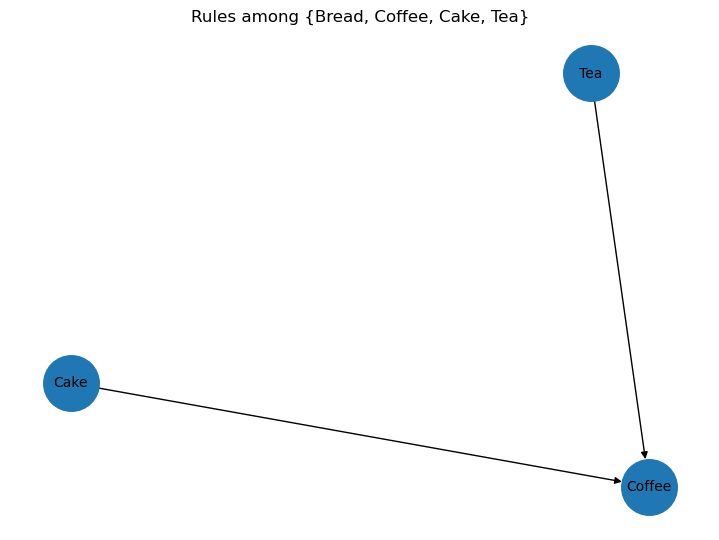

In [ ]:
import networkx as nx

focus = {'Bread','Coffee','Cake','Tea'}
sub = rules_b[
    rules_b['antecedents'].apply(lambda s: s.issubset(focus)) &
    rules_b['consequents'].apply(lambda s: s.issubset(focus))
].copy()

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake, Tea}")
plt.show()


## 8) Wrap-up
- Difference between **Apriori** and **FP-Growth** in one sentence:  
  Answer: `Apriori generates candidate itemsets and scans the database multiple times using the downward-closure property, while FP-Growth avoids candidate generation by compressing the data into an FP-tree and mining conditional pattern bases/trees.`
- Why do we need **lift** in addition to support & confidence?  
  Answer: `Because confidence can be misleading when the consequent is very common (base-rate / “milk trap”), and lift corrects for that by comparing the observed co-occurrence to what we would expect if the items were independent (lift > 1 positive association, = 1 independent, < 1 negative association).`
